In [383]:
import json

import cmasher as cmr
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
from matplotlib import cm
from scipy.signal import savgol_filter

In [384]:
sim = "m12i"
snap_lim = 46  # 46 for all except m12m which is 102

tbin_num_i = 6

# about 2 minutes to run on 101 iterations
it_min = 0
it_max = 100

sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = pub_snaps["index"].to_numpy()
time_lst = pub_snaps["time_Gyr"].to_numpy()

snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].to_numpy()
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()

all_data = sim_dir + "/" + sim + "/" + sim + "_res7100/" + "snapshot_times.txt"
all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
all_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

grp_file = sim_dir + sim + "/" + "gc_groups.json"
with open(grp_file, "r") as file:
    grp_dict = json.load(file)

ex_grp_lst = np.array([int(grp) for grp in grp_dict[sim].keys() if int(grp) != 0])
ex_grp_lst

array([ 1920378,  4414957,  8580896, 13687078, 16199669, 19898495])

In [385]:
def get_it_dict(time_lst, ex_grp_lst, tbin_con_dict):
    it_dict = {gc_utils.iteration_name(it): {} for it in range(it_min, it_max + 1)}

    for it_id in it_dict.keys():
        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        gc_sur_lst = snp_dat_600["gc_id"][()]
        gp_sur_lst = snp_dat_600["group_id"][()]

        gc_dict = {gcid: {} for gcid, grp in zip(gc_sur_lst, gp_sur_lst) if grp in ex_grp_lst or grp == 0}

        it_dict[it_id] = gc_dict

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["et_norm"] = []
            it_dict[it_id][gcid]["jr"] = []
            it_dict[it_id][gcid]["jp"] = []
            it_dict[it_id][gcid]["jz"] = []
            it_dict[it_id][gcid]["r3d"] = []
            it_dict[it_id][gcid]["r2d"] = []
            it_dict[it_id][gcid]["z"] = []

    for it_id in it_dict.keys():
        src_dat = proc_data[it_id]["source"]
        ana_msk = src_dat["analyse_flag"][()] == 1

        for gcid in it_dict[it_id].keys():
            gcid_idx = np.where(src_dat["gc_id"][ana_msk] == gcid)[0][0]
            gcid_grp = src_dat["group_id"][ana_msk][gcid_idx]

            if gcid_grp == 0:
                tvar = "form_time"
                grp_type = "in_situ"
                tbin_con = "tbin_con_i"
            else:
                tvar = "t_acc"
                grp_type = "ex_situ"
                tbin_con = "tbin_con_e"

            tval = src_dat[tvar][ana_msk][gcid_idx]
            it_dict[it_id][gcid]["tval"] = tval
            it_dict[it_id][gcid]["grp"] = gcid_grp
            it_dict[it_id][gcid]["grp_type"] = grp_type
            it_dict[it_id][gcid]["tval_grp"] = tbin_con_dict[tbin_con][tval]

    for it_id in it_dict.keys():
        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)

            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            acc_msk = snp_dat["now_accreted"][()] == 1
            bnd_msk = snp_dat["bound_flag"][()] == 1

            gc_snp_lst = snp_dat["gc_id"][acc_msk & bnd_msk]

            for gcid in it_dict[it_id].keys():
                if gcid not in gc_snp_lst:
                    it_dict[it_id][gcid]["et_norm"].append(0)
                    it_dict[it_id][gcid]["jr"].append(0)
                    it_dict[it_id][gcid]["jp"].append(0)
                    it_dict[it_id][gcid]["jz"].append(0)
                    it_dict[it_id][gcid]["r3d"].append(np.nan)
                    it_dict[it_id][gcid]["r2d"].append(np.nan)
                    it_dict[it_id][gcid]["z"].append(np.nan)

                else:
                    gcid_idx = np.where(snp_dat["gc_id"][acc_msk & bnd_msk] == gcid)[0][0]
                    et_norm = snp_dat["et_norm"][acc_msk & bnd_msk][gcid_idx]
                    j_cyl = snp_dat["j.cyl"][acc_msk & bnd_msk][gcid_idx]
                    pos_cyl = snp_dat["pos.cyl"][acc_msk & bnd_msk][gcid_idx]
                    r3d = snp_dat["r"][acc_msk & bnd_msk][gcid_idx]

                    it_dict[it_id][gcid]["et_norm"].append(et_norm)
                    it_dict[it_id][gcid]["jr"].append(j_cyl[0])
                    it_dict[it_id][gcid]["jp"].append(j_cyl[1])
                    it_dict[it_id][gcid]["jz"].append(j_cyl[2])
                    it_dict[it_id][gcid]["r3d"].append(r3d)
                    it_dict[it_id][gcid]["r2d"].append(pos_cyl[0])
                    it_dict[it_id][gcid]["z"].append(pos_cyl[2])

    tdiff = np.diff(time_lst)
    # weigh = tdiff / np.nansum(tdiff)
    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["det_norm"] = np.diff(it_dict[it_id][gcid]["et_norm"])
            it_dict[it_id][gcid]["djr"] = np.diff(it_dict[it_id][gcid]["jr"])
            it_dict[it_id][gcid]["djp"] = np.diff(it_dict[it_id][gcid]["jp"])
            it_dict[it_id][gcid]["djz"] = np.diff(it_dict[it_id][gcid]["jz"])

            all_zeros = not np.any(it_dict[it_id][gcid]["det_norm"])
            if all_zeros:
                it_dict[it_id][gcid]["det_norm_path"] = np.nan
                it_dict[it_id][gcid]["det_norm_net"] = np.nan

                it_dict[it_id][gcid]["djr_path"] = np.nan
                it_dict[it_id][gcid]["djr_net"] = np.nan

                it_dict[it_id][gcid]["djp_path"] = np.nan
                it_dict[it_id][gcid]["djp_net"] = np.nan

                it_dict[it_id][gcid]["djz_path"] = np.nan
                it_dict[it_id][gcid]["djz_net"] = np.nan

                it_dict[it_id][gcid]["first_term"] = 0
                it_dict[it_id][gcid]["last_term"] = 0
                continue

            first_term_idx = np.min(np.nonzero(it_dict[it_id][gcid]["et_norm"]))
            last_term_idx = np.max(np.nonzero(it_dict[it_id][gcid]["et_norm"]))

            it_dict[it_id][gcid]["det_norm"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djr"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djp"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djz"][first_term_idx - 1] = 0

            # if GC does not survive to z = 0
            # this just here as an ensurance as by selection they survive to z = 0
            if last_term_idx < len(it_dict[it_id][gcid]["det_norm"]) - 1:
                it_dict[it_id][gcid]["det_norm"][last_term_idx] = 0
                it_dict[it_id][gcid]["djr"][last_term_idx] = 0
                it_dict[it_id][gcid]["djp"][last_term_idx] = 0
                it_dict[it_id][gcid]["djz"][last_term_idx] = 0

            det_norm_net = (
                it_dict[it_id][gcid]["et_norm"][last_term_idx]
                - it_dict[it_id][gcid]["et_norm"][first_term_idx]
            )
            djr_net = it_dict[it_id][gcid]["jr"][last_term_idx] - it_dict[it_id][gcid]["jr"][first_term_idx]
            djp_net = it_dict[it_id][gcid]["jp"][last_term_idx] - it_dict[it_id][gcid]["jp"][first_term_idx]
            djz_net = it_dict[it_id][gcid]["jz"][last_term_idx] - it_dict[it_id][gcid]["jz"][first_term_idx]

            ##### Weightings
            nonzero_msk = np.array(it_dict[it_id][gcid]["det_norm"]) != 0
            tdiff_msk = tdiff[nonzero_msk]
            weigh = np.zeros_like(tdiff, dtype=float)
            weigh[nonzero_msk] = tdiff[nonzero_msk] / np.sum(tdiff_msk)

            it_dict[it_id][gcid]["det_norm_path"] = np.sum(np.abs(it_dict[it_id][gcid]["det_norm"]))
            it_dict[it_id][gcid]["det_norm_path_w"] = np.sum(np.abs(it_dict[it_id][gcid]["det_norm"]) * weigh)
            it_dict[it_id][gcid]["det_norm_net"] = np.abs(det_norm_net)

            it_dict[it_id][gcid]["djr_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djr"]))
            it_dict[it_id][gcid]["djr_path_w"] = np.sum(np.abs(it_dict[it_id][gcid]["djr"]) * weigh)
            it_dict[it_id][gcid]["djr_net"] = np.abs(djr_net)

            it_dict[it_id][gcid]["djp_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djp"]))
            it_dict[it_id][gcid]["djp_path_w"] = np.sum(np.abs(it_dict[it_id][gcid]["djp"]) * weigh)
            it_dict[it_id][gcid]["djp_net"] = np.abs(djp_net)

            it_dict[it_id][gcid]["djz_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djz"]))
            it_dict[it_id][gcid]["djz_path_w"] = np.sum(np.abs(it_dict[it_id][gcid]["djz"]) * weigh)
            it_dict[it_id][gcid]["djz_net"] = np.abs(djz_net)

            it_dict[it_id][gcid]["first_term"] = first_term_idx
            it_dict[it_id][gcid]["last_term"] = last_term_idx

    # add averages
    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            r3d = np.array(it_dict[it_id][gcid]["r3d"][:-1])
            r3d_msk = ~np.isnan(r3d)
            num = np.nansum(r3d[r3d_msk] * tdiff[r3d_msk]) if len(r3d_msk) > 0 else np.nan
            den = np.sum(tdiff[r3d_msk])
            it_dict[it_id][gcid]["r3d_avg"] = num / den if den > 0 else np.nan

            r2d = np.array(it_dict[it_id][gcid]["r2d"][:-1])
            r2d_msk = ~np.isnan(r2d)
            num = np.nansum(r2d[r2d_msk] * tdiff[r2d_msk]) if len(r2d_msk) > 0 else np.nan
            den = np.sum(tdiff[r2d_msk])
            it_dict[it_id][gcid]["r2d_avg"] = num / den if den > 0 else np.nan

            z = np.array(it_dict[it_id][gcid]["z"][:-1])
            z_msk = ~np.isnan(z)
            num = np.nansum(z[z_msk] * tdiff[z_msk]) if len(z_msk) > 0 else np.nan
            den = np.sum(tdiff[z_msk])
            it_dict[it_id][gcid]["z_avg"] = num / den if den > 0 else np.nan

    return it_dict

In [386]:
def get_tcon(tunq, group_type):
    if group_type == "in_situ":
        vmin, vmax = np.min(tunq), np.max(tunq)
        bin_edges = np.linspace(vmin, vmax, tbin_num_i + 1)
        bin_indices = np.digitize(tunq, bin_edges, right=False) - 1
        bin_indices[bin_indices == tbin_num_i] = tbin_num_i - 1

        tbin_con = {t: b for t, b in zip(tunq, bin_indices)}

        t_dict = {}
        for i in range(tbin_num_i):
            t_dict[i] = {}
            t_dict[i]["edge_l"] = bin_edges[i]
            t_dict[i]["edge_u"] = bin_edges[i + 1]
    else:
        t_dict = {}
        for i in range(len(tunq)):
            t_dict[i] = {}
            t_dict[i]["edge_l"] = tunq[i]
            t_dict[i]["edge_u"] = tunq[i]

        tbin_con = {t: b for t, b in zip(tunq, t_dict.keys())}

    return t_dict, tbin_con

In [387]:
tgrp_i = np.array([])
tgrp_e = np.array([])

tvar_i = "form_time"
tvar_e = "t_acc"

for it_id in proc_data.keys():
    snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
    src_dat = proc_data[it_id]["source"]
    ana_msk = src_dat["analyse_flag"][()] == 1

    gc_src = src_dat["gc_id"][ana_msk]

    grp_msk_600_i = snp_dat_600["group_id"][()] == 0
    gc_sur_i = snp_dat_600["gc_id"][grp_msk_600_i]
    gc_msk_i = np.isin(gc_src, gc_sur_i)
    tit_i = src_dat[tvar_i][ana_msk]
    tit_i = tit_i[gc_msk_i]
    tgrp_i = np.concatenate((tgrp_i, tit_i))

    grp_msk_600_e = np.isin(snp_dat_600["group_id"][()], ex_grp_lst)
    gc_sur_e = snp_dat_600["gc_id"][grp_msk_600_e]
    gc_msk_e = np.isin(gc_src, gc_sur_e)
    tit_e = src_dat[tvar_e][ana_msk]
    tit_e = tit_e[gc_msk_e]
    tgrp_e = np.concatenate((tgrp_e, tit_e))

t_dict_i, tbin_con_i = get_tcon(np.unique(tgrp_i), "in_situ")
t_dict_e, tbin_con_e = get_tcon(np.unique(tgrp_e), "ex_situ")

tbin_con_dict = {"tbin_con_i": tbin_con_i, "tbin_con_e": tbin_con_e}
t_dict = {"t_dict_i": t_dict_i, "t_dict_e": t_dict_e}

In [388]:
t_dict

{'t_dict_i': {0: {'edge_l': 0.848107044, 'edge_u': 1.5505297526666668},
  1: {'edge_l': 1.5505297526666668, 'edge_u': 2.2529524613333334},
  2: {'edge_l': 2.2529524613333334, 'edge_u': 2.95537517},
  3: {'edge_l': 2.95537517, 'edge_u': 3.657797878666667},
  4: {'edge_l': 3.657797878666667, 'edge_u': 4.360220587333333},
  5: {'edge_l': 4.360220587333333, 'edge_u': 5.062643296}},
 't_dict_e': {0: {'edge_l': 2.359, 'edge_u': 2.359},
  1: {'edge_l': 3.608, 'edge_u': 3.608},
  2: {'edge_l': 5.395, 'edge_u': 5.395},
  3: {'edge_l': 7.822, 'edge_u': 7.822},
  4: {'edge_l': 9.148, 'edge_u': 9.148},
  5: {'edge_l': 11.161, 'edge_u': 11.161}}}

In [389]:
it_dict = get_it_dict(time_lst, ex_grp_lst, tbin_con_dict)

In [390]:
def get_kde(x, y, xlim, ylim, grid_size=200):
    # Stack coordinates
    xy = np.vstack([x, y])

    # Compute KDE
    kde = stats.gaussian_kde(xy)

    # Create grid
    xmin, xmax = xlim
    ymin, ymax = ylim
    X, Y = np.mgrid[
        xmin : xmax : grid_size * 1j, ymin : ymax : grid_size * 1j
    ]  # use complex step for number of points
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Evaluate KDE
    Z = np.reshape(kde(positions).T, X.shape)

    # Apply bounds mask
    mask = (X >= 0) & (Y >= 0) & (Y <= X)  # only allow x>=0, y>=0, y<=x
    Z_masked = np.where(mask, Z, 0)  # set values outside bounds to 0

    return Z_masked

In [391]:
def contour_level_from_mass(Z, X, Y, frac=0.75):
    """
    Compute contour level that encloses `frac` of the total probability mass.
    Z : 2D KDE array
    X, Y : 2D meshgrid arrays
    frac : fraction of mass to enclose (0-1)
    """
    dx = X[1, 0] - X[0, 0]  # grid spacing in x
    dy = Y[0, 1] - Y[0, 0]  # grid spacing in y
    cell_area = dx * dy

    Z_flat = Z.ravel()
    Z_sort = np.sort(Z_flat)[::-1]  # sort descending
    cumsum = np.cumsum(Z_sort * cell_area)
    cumsum /= cumsum[-1]  # normalize to 1

    idx = np.searchsorted(cumsum, frac)
    return Z_sort[idx]

In [ ]:
def plot_cont(ax, var, group_type, cont_level=0.75, grid_size=250, plt_y=True, weights=False):
    cmap = "jet"
    vmin = 0
    vmax = 14
    sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))

    var_dict = {
        "et_norm": {
            "ylab": r"$\epsilon_{net}$",
            "xlab": r"$\epsilon_{path}$",
            "ylim": 1,
            "xlim": 1.2,
        },
        "jr": {
            "ylab": r"J$_{R, net}$ (kpc km s$^{-1}$)",
            "xlab": r"J$_{R, path}$ (kpc km s$^{-1}$)",
            "ylim": 3000,
            "xlim": 6000,
        },
        "jp": {
            "ylab": r"J$_{\phi,\ \mathrm{net}}$ (kpc km s$^{-1}$)",
            "xlab": r"J$_{\phi,\ \mathrm{path}}$ (kpc km s$^{-1}$)",
            "ylim": 5000,
            "xlim": 15000,
        },
        "jz": {
            "ylab": r"J$_{z, net}$ (kpc km s$^{-1}$)",
            "xlab": r"J$_{z, path}$ (kpc km s$^{-1}$)",
            "ylim": 5000,
            "xlim": 15000,
        },
    }

    xmax = var_dict[var]["xlim"]
    ymax = var_dict[var]["ylim"]

    if group_type == "in_situ":
        t_dict_type = "t_dict_i"
    elif group_type == "ex_situ":
        t_dict_type = "t_dict_e"

    plt_dict = {
        tval_grp: {it_id: {"x": [], "y": []} for it_id in it_dict.keys()}
        for tval_grp in t_dict[t_dict_type].keys()
    }

    for it_id in it_dict:
        for gcid in it_dict[it_id]:
            grp_type = it_dict[it_id][gcid]["grp_type"]
            if grp_type != group_type:
                continue

            tval_grp = it_dict[it_id][gcid]["tval_grp"]

            if weights:
                plt_dict[tval_grp][it_id]["x"].append(it_dict[it_id][gcid]["d" + var + "_path_w"])

            else:
                plt_dict[tval_grp][it_id]["x"].append(it_dict[it_id][gcid]["d" + var + "_path"])

            plt_dict[tval_grp][it_id]["y"].append(it_dict[it_id][gcid]["d" + var + "_net"])

    for tval_grp in t_dict[t_dict_type].keys():
        tval_cen = np.average(
            (t_dict[t_dict_type][tval_grp]["edge_l"], t_dict[t_dict_type][tval_grp]["edge_u"])
        )
        color = sm.to_rgba(tval_cen)

        kde_lst = []
        for it_id in it_dict:
            x = plt_dict[tval_grp][it_id]["x"]
            y = plt_dict[tval_grp][it_id]["y"]

            if len(x) <= 2:
                continue
            z = get_kde(x, y, (0, xmax), (0, ymax), grid_size)
            kde_lst.append(z)

        if len(kde_lst) == 0:
            continue

        Z_mean = np.mean(kde_lst, axis=0)
        # Z_mean = np.median(kde_lst, axis=0)

        X, Y = np.mgrid[0 : xmax : grid_size * 1j, 0 : ymax : grid_size * 1j]
        level = contour_level_from_mass(Z_mean, X, Y, frac=cont_level)
        ax.contour(X, Y, Z_mean, levels=[level], colors=[color])

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)

    max_val = np.max((xmax, ymax))
    ax.plot([0, max_val], [0, max_val], c="k", zorder=10)

    ax.set_xlabel(var_dict[var]["xlab"], fontsize=11)
    ax.set_ylabel(var_dict[var]["ylab"], fontsize=11)

    if not plt_y:
        ax.set_ylabel("")
        ax.set_yticklabels([])

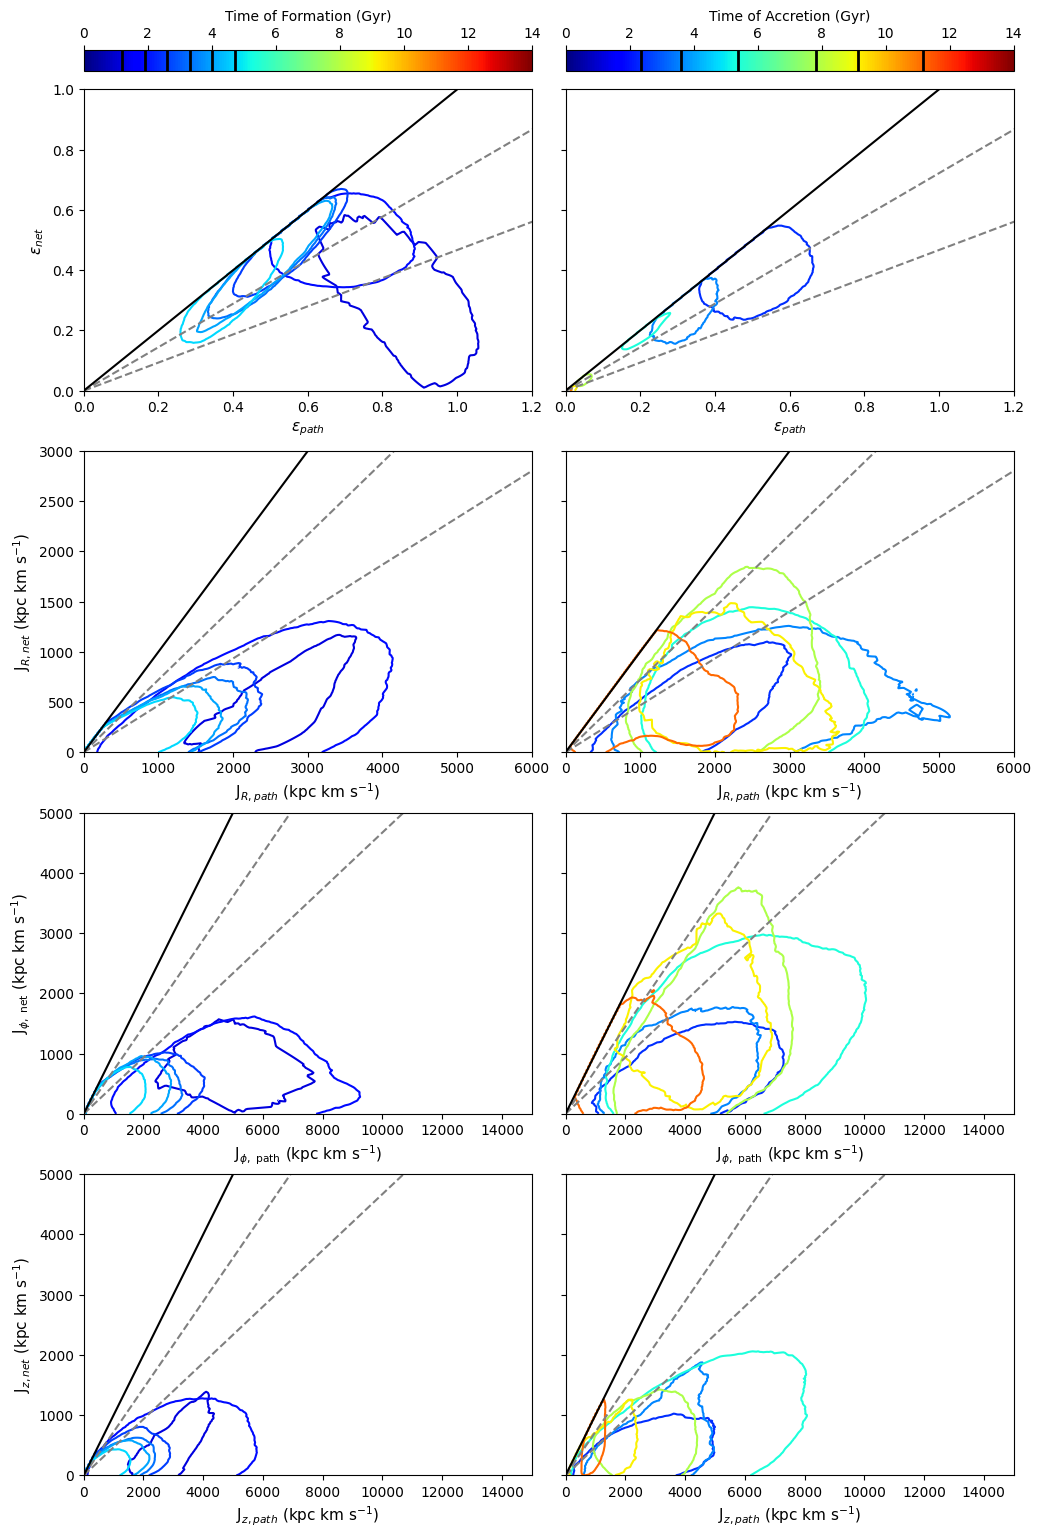

In [ ]:
var_lst = ["et_norm", "jr", "jp", "jz"]
group_types = ["in_situ", "ex_situ"]

# following values from "random_walk.ipynb"
kmin = 0.49
kmax = 0.73

fig, axs = plt.subplots(4, 2, figsize=(12, 18), sharey=False, sharex=False)
plt.subplots_adjust(wspace=0.075)

plt_y = True
for j, group_type in enumerate(group_types):
    if j == 1:
        plt_y = False
    for i, var in enumerate(var_lst):
        ax = axs[i, j]
        plot_cont(ax, var, group_type, cont_level=0.75, grid_size=250, plt_y=plt_y)
        ax.plot([0, 15000], [0, kmin * 15000], c="grey", ls="--")
        ax.plot([0, 15000], [0, kmax * 15000], c="grey", ls="--")


# --- create general colorbars for each column ---
cmap = "jet"
vmin = 0
vmax = 14
sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

# --- left column ---
left_pos = axs[0, 0].get_position()
top_pos = axs[0, 0].get_position()
cbar_ax_left = fig.add_axes(
    [
        left_pos.x0,
        top_pos.y1 + 0.01,  # space above subplot
        left_pos.width,
        0.012,
    ]
)
cbar_left = fig.colorbar(sm, cax=cbar_ax_left, orientation="horizontal")
cbar_left.set_label("Time of Formation (Gyr)")
cbar_left.ax.xaxis.set_ticks_position("top")
cbar_left.ax.xaxis.set_label_position("top")

# --- right column ---
right_pos = axs[0, 1].get_position()
top_pos = axs[0, 1].get_position()
cbar_ax_right = fig.add_axes([right_pos.x0, top_pos.y1 + 0.01, right_pos.width, 0.012])
cbar_right = fig.colorbar(sm, cax=cbar_ax_right, orientation="horizontal")
cbar_right.set_label("Time of Accretion (Gyr)")
cbar_right.ax.xaxis.set_ticks_position("top")
cbar_right.ax.xaxis.set_label_position("top")

cbar = [cbar_left, cbar_right]

for i, t_dict_type in enumerate(t_dict.keys()):
    for tval_grp in t_dict[t_dict_type].keys():
        tval_cen = np.average(
            (t_dict[t_dict_type][tval_grp]["edge_l"], t_dict[t_dict_type][tval_grp]["edge_u"])
        )
        # cbar[i].ax.hlines(tval_cen, ymin=0, ymax=1, colors="k", linewidth=2)
        cbar[i].ax.axvline(tval_cen, color="k", linewidth=2)

In [593]:
def plot_kvar(var, win_lst, it_dict, time_lst, grp="in_situ"):
    k_avg = []
    k_std = []
    t_hld = []

    for win in win_lst:
        idxl = win["idxl"]
        idxu = win["idxu"]

        t_cen = np.average((time_lst[idxl], time_lst[idxu]))

        tmin = time_lst[idxl]

        it_k = []
        for it_id in it_dict:
            gc_k = []
            for gcid in it_dict[it_id]:
                if it_dict[it_id][gcid]["grp_type"] != grp:
                    continue
                if it_dict[it_id][gcid]["tval"] < tmin:
                    d_arr = it_dict[it_id][gcid]["d" + var]
                    gc_path = np.nansum(np.abs(d_arr[idxl:idxu]))
                    gc_net = np.abs(it_dict[it_id][gcid][var][idxu] - it_dict[it_id][gcid][var][idxl])
                    gc_k.append(gc_net / gc_path)
                else:
                    continue

            if len(gc_k) != 0:
                it_k.append(np.nanmean(gc_k))
                # it_k.append(np.nanmedian(gc_k))

        if len(it_k) != 0:
            k_avg.append(np.nanmean(it_k))
            k_std.append(np.nanstd(it_k))
            t_hld.append(t_cen)

    return k_avg, k_std, t_hld

In [485]:
# time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()
# # time_lst = time_lst[:-10]

# # mul = 8

# # ########################################

# # t_diff = np.median(np.diff(time_lst))

# # dt = mul * t_diff
# dt = 4  # Gyr

# win_lst = []

# idxl = 0
# tl = time_lst[idxl]
# tu = np.max(time_lst[time_lst <= tl + dt])
# idxu = np.argmin(np.abs(time_lst - tu))

# win_lst.append({"idxl": idxl, "idxu": idxu})

# while idxu < len(time_lst) - 1:
#     idxl += 1
#     tl = time_lst[idxl]
#     tu = np.max(time_lst[time_lst <= tl + dt])
#     idxu = np.argmin(np.abs(time_lst - tu))

#     win_lst.append({"idxl": idxl, "idxu": idxu})

In [592]:
win_lst = []

idxl = 0
idxu = 10

win_lst.append({"idxl": 0, "idxu": 10})

# while idxu < len(time_lst) - 11:
while idxu < len(time_lst) - 1:
    idxl += 1
    idxu += 1
    win_lst.append({"idxl": idxl, "idxu": idxu})

win_lst

[{'idxl': 0, 'idxu': 10},
 {'idxl': 1, 'idxu': 11},
 {'idxl': 2, 'idxu': 12},
 {'idxl': 3, 'idxu': 13},
 {'idxl': 4, 'idxu': 14},
 {'idxl': 5, 'idxu': 15},
 {'idxl': 6, 'idxu': 16},
 {'idxl': 7, 'idxu': 17},
 {'idxl': 8, 'idxu': 18},
 {'idxl': 9, 'idxu': 19},
 {'idxl': 10, 'idxu': 20},
 {'idxl': 11, 'idxu': 21},
 {'idxl': 12, 'idxu': 22},
 {'idxl': 13, 'idxu': 23},
 {'idxl': 14, 'idxu': 24},
 {'idxl': 15, 'idxu': 25},
 {'idxl': 16, 'idxu': 26},
 {'idxl': 17, 'idxu': 27},
 {'idxl': 18, 'idxu': 28},
 {'idxl': 19, 'idxu': 29},
 {'idxl': 20, 'idxu': 30},
 {'idxl': 21, 'idxu': 31}]

In [465]:
# k_lst = [
#     0.5655655655655656,
#     0.5855855855855856,
#     0.6246246246246246,
#     0.6066066066066066,
#     0.5965965965965966,
#     0.5965965965965966,
#     0.5945945945945946,
#     0.5965965965965966,
#     0.5975975975975976,
#     0.6036036036036035,
#     0.6006006006006006,
#     0.5875875875875876,
#     0.5945945945945946,
#     0.6066066066066066,
#     0.6186186186186187,
#     0.6406406406406406,
#     0.6796796796796797,
#     0.7377377377377378,
#     0.914914914914915,
#     0.9209209209209209,
#     0.8948948948948949,
#     0.5955955955955956,
# ]

# t_k_lst = []
# for win in win_lst:
#     idxl = win["idxl"]
#     idxu = win["idxu"]

#     t_cen = np.average((time_lst[idxl], time_lst[idxu]))
#     t_k_lst.append(t_cen)

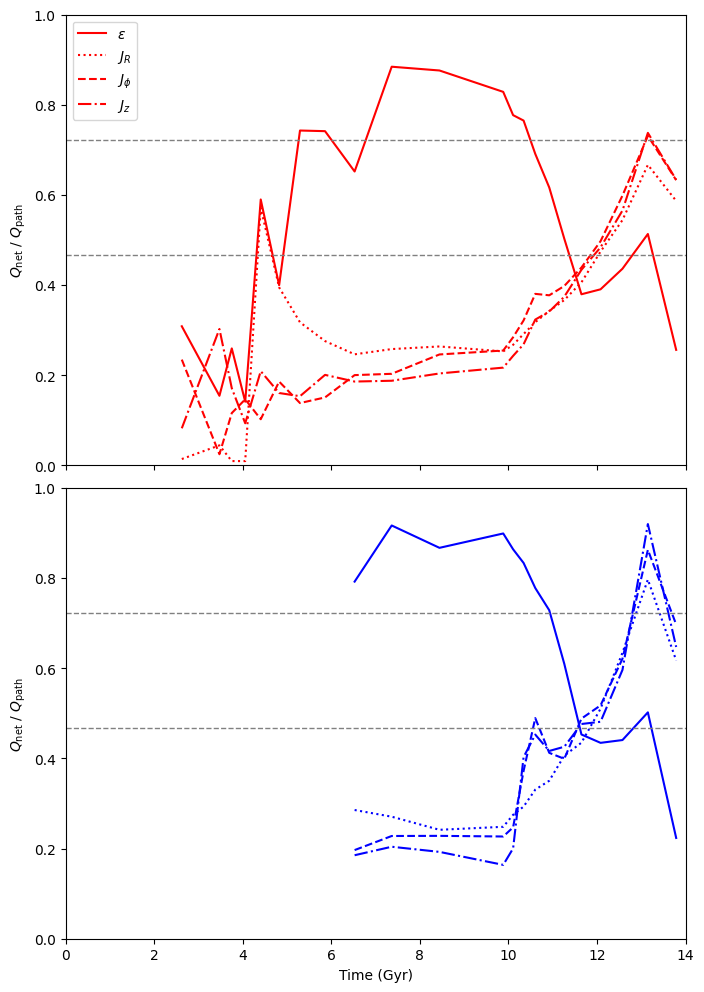

In [594]:
var_lst = ["et_norm", "jr", "jp", "jz"]
plt_lin = ["solid", "dotted", "dashed", "dashdot"]
leg_lst = [r"$\epsilon$", r"$J_{R}$", r"$J_{\phi}$", r"$J_{z}$"]

fig, axs = plt.subplots(2, 1, figsize=(8, 12), sharey=True, sharex=True)
plt.subplots_adjust(hspace=0.05)

for var, lin, leg in zip(var_lst, plt_lin, leg_lst):
    k_avg, k_std, t_hld = plot_kvar(var, win_lst, it_dict, time_lst, grp="in_situ")
    axs[0].plot(t_hld, k_avg, c="r", ls=lin, label=leg)

    k_avg, k_std, t_hld = plot_kvar(var, win_lst, it_dict, time_lst, grp="ex_situ")
    axs[1].plot(t_hld, k_avg, c="b", ls=lin, label=leg)

axs[0].set_ylabel(r"$Q_{\rm net}$ / $Q_{\rm path}$")
axs[1].set_ylabel(r"$Q_{\rm net}$ / $Q_{\rm path}$")
# axs[0].set_xlabel("Time (Gyr)")
axs[1].set_xlabel("Time (Gyr)")

# axs[0].set_title("In-Situ")
# axs[1].set_title("Ex-Situ")

axs[0].legend(loc="upper left")
# axs[1].legend(loc="lower right")

for ax in axs:
    # ax.plot(t_k_lst, k_lst, c="grey", ls="--", lw=1)
    ax.plot([0, 14], [kmin, kmin], c="grey", ls="--", lw=1)
    ax.plot([0, 14], [kmax, kmax], c="grey", ls="--", lw=1)

    ax.set_xlim(0, 14)
    ax.set_ylim(0, 1)

axs[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

In [423]:
def var_plot(var, grp):
    var_dict = {
        "et_norm": {"d_max": 1.5, "d_bin": 0.1, "vmax": 0.6, "vsize": 0.05, "label": r"$\Delta\epsilon$"},
        "jr": {"d_max": 2000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"$\Delta$J$_{R}$"},
        "jp": {"d_max": 2000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"$\Delta$J$_{\phi}$"},
        "jz": {"d_max": 2000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"$\Delta$J$_{z}$"},
    }

    d_max = var_dict[var]["d_max"]

    # --- SETUP ---
    n_snaps = len(pub_snaps[pub_snaps["index"] >= snap_lim])  # number of snapshots >= snap_lim
    d_bin_size = var_dict[var]["d_bin"]
    d_bins = np.arange(-d_max, d_max + d_bin_size, d_bin_size)
    d_centres_in = 0.5 * (d_bins[:-1] + d_bins[1:])
    d_bin_num = len(d_bins) - 1

    # Arrays to store normalized counts per bin
    d_bin_cnt = np.zeros((n_snaps, d_bin_num))

    # Loop through snapshots
    k = 0
    for i, snap in enumerate(snap_lst):
        # snap_id = gc_utils.snapshot_name(snap)
        time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]

        # --- COLLECT dvar for ALL GCs alive at this time ---
        d_path_lst = []
        for it_id in it_dict:
            for gcid in it_dict[it_id]:
                # if it_dict[it_id][gcid]["grp_type"] != "in_situ":
                if it_dict[it_id][gcid]["grp"] != grp:
                    continue
                if it_dict[it_id][gcid]["tval"] <= time:
                    d_arr = it_dict[it_id][gcid]["d" + var]
                    d_val = np.nansum(d_arr[: i - 1]) if i >= 2 else 0.0
                    d_path_lst.append(d_val)

        d_path_lst = np.array(d_path_lst)
        d_tot = len(d_path_lst)

        # --- BINNING ---
        for j in range(d_bin_num):
            d_min = d_bins[j]
            d_max = d_bins[j + 1]

            d_msk = (d_path_lst >= d_min) & (d_path_lst < d_max)
            z_msk = d_path_lst != 0  # optional: exclude zero change
            d_cnt = np.sum(d_msk & z_msk)

            if d_tot > 0:
                d_bin_cnt[k, j] += d_cnt / d_tot

        k += 1

        plot_dict = {
            "x": pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy(),
            "y": d_centres_in,
            "z": d_bin_cnt.T,
            "vmin": 0,
            "vmax": var_dict[var]["vmax"],
            "vsize": var_dict[var]["vsize"],
            "label": var_dict[var]["label"],
            "d_max": d_max,
            "d_bin_size": d_bin_size,
        }

    return plot_dict

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_65466/3234444389.py:56: RuntimeWarning: invalid value encountered in divide
  avg_line = np.nansum(y[:, None] * z, axis=0) / np.nansum(z, axis=0)
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_65466/3234444389.py:56: RuntimeWarning: invalid value encountered in divide
  avg_line = np.nansum(y[:, None] * z, axis=0) / np.nansum(z, axis=0)
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_65466/3234444389.py:56: RuntimeWarning: invalid value encountered in divide
  avg_line = np.nansum(y[:, None] * z, axis=0) / np.nansum(z, axis=0)


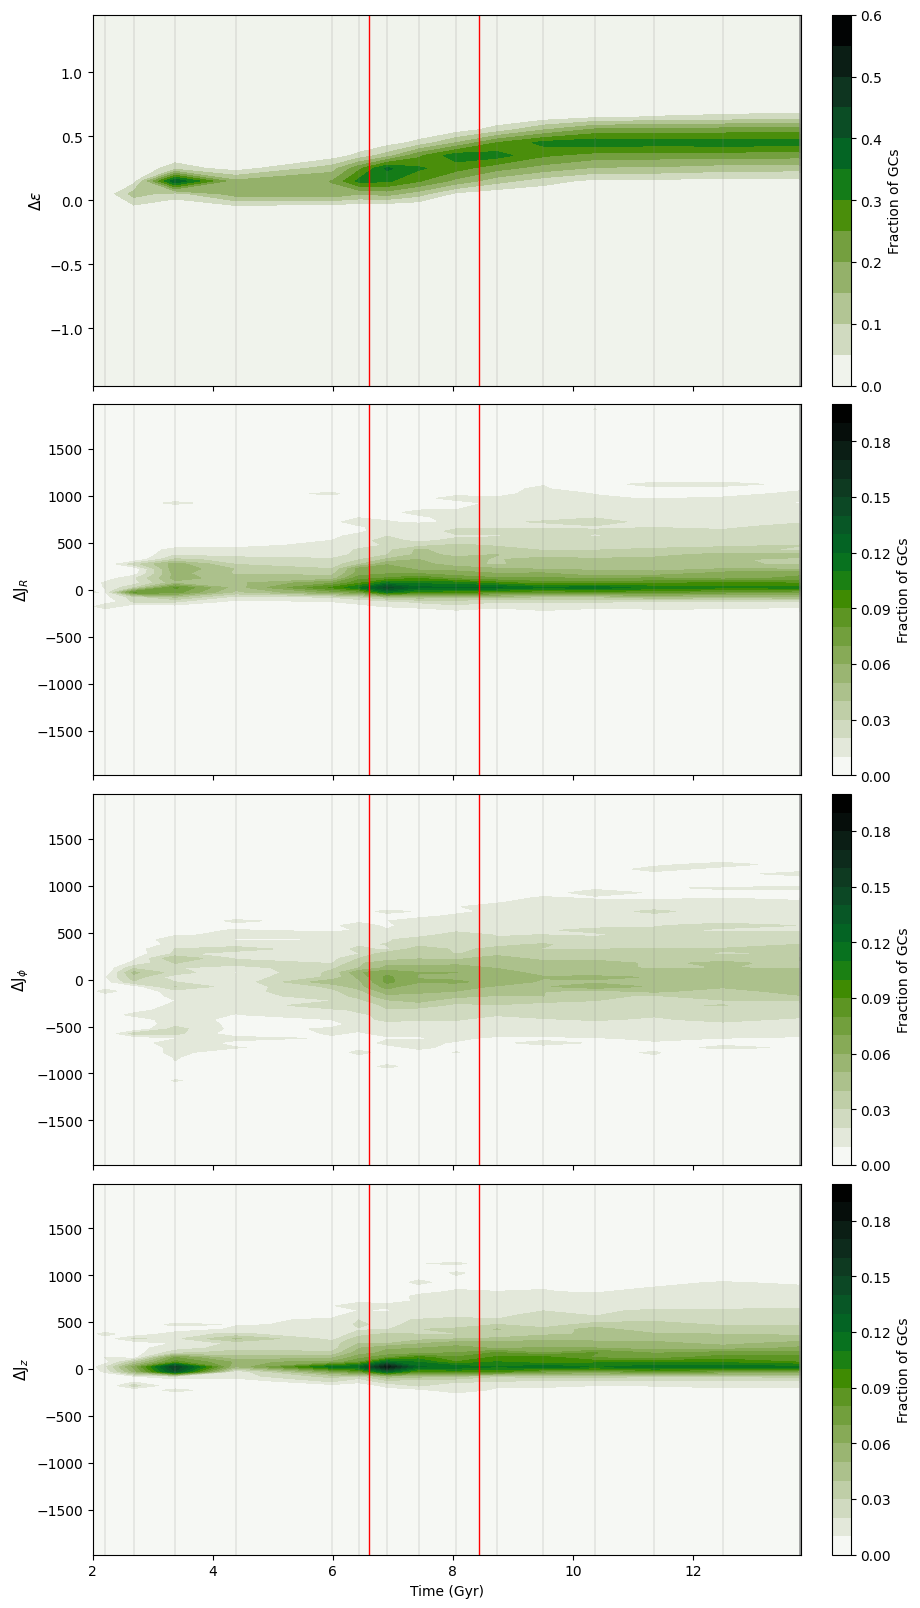

In [424]:
kappa_dict = {
    "m12b": {"kappa_02": 5.29, "kappa_04": 6.94},
    "m12c": {"kappa_02": 6.80, "kappa_04": 8.49},
    "m12f": {"kappa_02": 3.86, "kappa_04": 6.87},
    "m12i": {"kappa_02": 6.61, "kappa_04": 8.44},
    "m12m": {"kappa_02": 3.57, "kappa_04": 4.03},
}

kappa_02 = kappa_dict[sim]["kappa_02"]
kappa_04 = kappa_dict[sim]["kappa_04"]

fig, axs = plt.subplots(4, 1, figsize=(10, 20), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0.05)

var_lst = ["et_norm", "jr", "jp", "jz"]

for i, var in enumerate(var_lst):
    ax = axs[i]
    plot_dict = var_plot(var, 0)
    contour_mig = ax.contourf(
        plot_dict["x"],
        plot_dict["y"],
        plot_dict["z"],
        cmap=cmr.jungle_r,
        levels=np.arange(plot_dict["vmin"], plot_dict["vmax"] + plot_dict["vsize"], plot_dict["vsize"]),
    )

    # Colorbar to the right of each subplot
    cbar = fig.colorbar(contour_mig, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Fraction of GCs", fontsize=10)

    # Labels
    if i == 3:
        ax.set_xlabel("Time (Gyr)", fontsize=10)
    ax.set_ylabel(plot_dict["label"], fontsize=11)
    if i != 3:
        ax.set_xticklabels([])

    # Vertical time lines
    for xi in plot_dict["x"]:
        ax.plot([xi, xi], [-plot_dict["d_max"], plot_dict["d_max"]], c="grey", lw=0.2)

    ax.set_ylim(
        -(plot_dict["d_max"] - plot_dict["d_bin_size"] / 2), plot_dict["d_max"] - plot_dict["d_bin_size"] / 2
    )
    ax.plot([kappa_02, kappa_02], [-plot_dict["d_max"], plot_dict["d_max"]], c="r", lw=1)
    ax.plot([kappa_04, kappa_04], [-plot_dict["d_max"], plot_dict["d_max"]], c="r", lw=1)
    ax.set_xlim(2, np.max(plot_dict["x"]))

    # Compute and plot average line
    z = plot_dict["z"]
    y = plot_dict["y"]
    x = plot_dict["x"]

    # Weighted average along y for each x
    avg_line = np.nansum(y[:, None] * z, axis=0) / np.nansum(z, axis=0)
    # ax.plot(x, avg_line, c="blue", lw=2, linestyle="--", label="Average")

# Checking Correlations

In [400]:
def return_kappa_co(sim, sim_dir, spec_type="s"):
    all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
    all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
    all_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    kin_file = sim_dir + sim + "/" + "galaxy_kinematics.json"
    with open(kin_file, "r") as file:
        kin_dict = json.load(file)

    time_lst = []
    kappa_co_lst = []
    for snap_id in kin_dict.keys():
        snp = int(snap_id[4:])
        tim = all_snaps[all_snaps["index"] == snp]["time_Gyr"].values[0]
        time_lst.append(tim)

        if spec_type == "s":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_s"])

        elif spec_type == "g":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_g"])

        elif spec_type == "sg":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_sg"])

        else:
            raise Warning("Wrong spec_type chosen")

    return time_lst, kappa_co_lst

In [401]:
def return_mass_plot(sim: str, sim_dir: str, smoothing: bool = True):
    all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
    all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
    all_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    sim_code_file = sim_dir + "simulation_codes.json"
    with open(sim_code_file, "r") as file:
        sim_codes = json.load(file)
    main_halo = sim_codes[sim]["halo"]
    Ob = sim_codes[sim]["Ob"]
    Om = sim_codes[sim]["Om"]
    fb = Ob / Om

    halt = gc_utils.get_halo_tree(sim, sim_dir)

    halo_idx = np.where(halt["tid"] == main_halo)[0][0]
    dm_mass_z0 = halt["mass"][halo_idx]
    mass_z0 = dm_mass_z0 / (1 - fb)

    time_lst = [0]
    mass_ratio_lst = [0]
    for snap in range(10, 601):
        time = all_snaps[all_snaps["index"] == snap]["time_Gyr"].values[0]

        halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
        halo_idx = np.where(halt["tid"] == halo_tid)[0][0]
        dm_mass = halt["mass"][halo_idx]
        mass = dm_mass / (1 - fb)
        mass_ratio = mass / mass_z0

        time_lst.append(time)
        mass_ratio_lst.append(mass_ratio)

    if smoothing:
        mass_ratio_lst = savgol_filter(mass_ratio_lst, window_length=50, polyorder=3)

    grp_file = sim_dir + sim + "/" + "gc_groups.json"
    with open(grp_file, "r") as file:
        grp_dict = json.load(file)
    # grp_lst = [int(grp) for grp in grp_dict[sim].keys() if int(grp) != 0]

    # acc_dict = {grp: {} for grp in grp_lst}
    acc_dict = {int(grp): {} for grp in grp_dict[sim].keys() if int(grp) != 0}

    for grp in acc_dict.keys():
        grp_idx = np.where(halt["tid"] == grp)[0][0]
        grp_snp = halt["snapshot"][grp_idx]
        grp_tim = all_snaps[all_snaps["index"] == grp_snp + 1]["time_Gyr"].values[0]
        acc_dict[grp] = grp_tim

    return mass_ratio_lst, time_lst, acc_dict

In [402]:
tmin = kappa_dict[sim]["kappa_02"]
tmin = 2

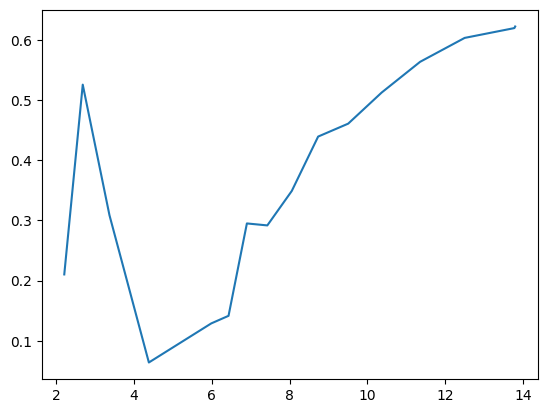

In [403]:
time_lst, kappa_co_lst = return_kappa_co(sim, sim_dir, spec_type="sg")

time_lst = np.array(time_lst)
kappa_co_lst = np.array(kappa_co_lst)

msk = time_lst >= tmin

time_lst = time_lst[msk]
kappa_co_lst = kappa_co_lst[msk]

plt.plot(time_lst, kappa_co_lst)

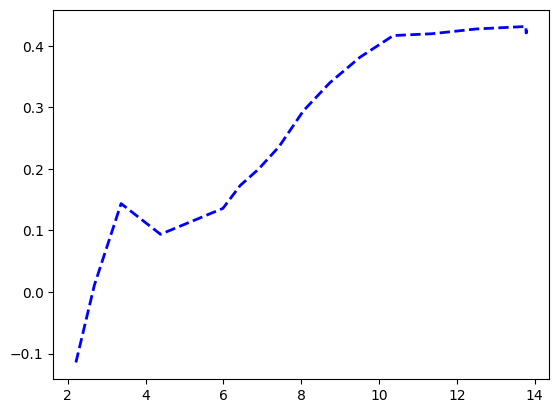

In [404]:
plot_dict = var_plot("et_norm", 0)

z = plot_dict["z"]
y = plot_dict["y"]
x = plot_dict["x"]

# Compute weighted average along y, safely handling zero columns
sum_z = np.nansum(z, axis=0)
sum_yz = np.nansum(y[:, None] * z, axis=0)
avg_line = np.divide(sum_yz, sum_z, out=np.full_like(sum_yz, np.nan), where=sum_z != 0)

# Mask x to start from tmin
msk = x >= tmin
x_masked = x[msk]
avg_masked = avg_line[msk]

# Plot the average line on top of contour
plt.plot(x_masked, avg_masked, c="blue", lw=2, linestyle="--", label="Average")

In [405]:
mass_ratio_lst, time_lst, acc_dict = return_mass_plot(sim, sim_dir, smoothing=True)

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.37s/it]


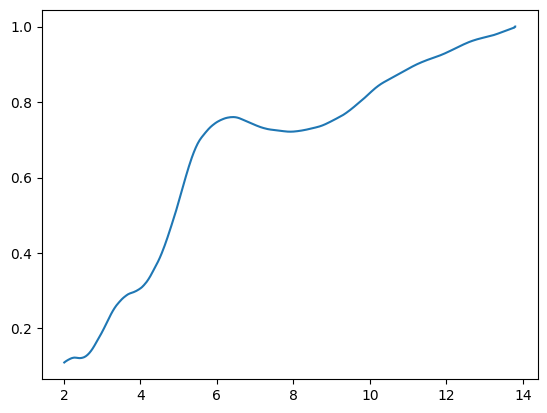

In [406]:
time_lst = np.array(time_lst)
mass_ratio_lst = np.array(mass_ratio_lst)

msk = time_lst >= tmin

time_lst = time_lst[msk]
mass_ratio_lst = mass_ratio_lst[msk]

plt.plot(time_lst, mass_ratio_lst)

In [407]:
common_values = time_lst[np.isin(time_lst, x_masked)]
msk = np.isin(time_lst, common_values)

mass_ratio_lst = mass_ratio_lst[msk]

In [408]:
stats.pearsonr(avg_masked, kappa_co_lst)

PearsonRResult(statistic=0.7963054643508184, pvalue=1.924731773342297e-06)

In [409]:
stats.pearsonr(avg_masked, mass_ratio_lst)

PearsonRResult(statistic=0.9259554216946396, pvalue=3.307686833843427e-11)

In [410]:
df = pd.DataFrame({"avg_masked": avg_masked, "kappa_co_lst": kappa_co_lst, "mass_ratio_lst": mass_ratio_lst})

In [411]:
pg.partial_corr(data=df, x="avg_masked", y="kappa_co_lst", covar="mass_ratio_lst", method="pearson")

,n,r,CI95%,p-val
pearson,25,0.646528,"[0.33, 0.83]",0.000641


In [412]:
pg.partial_corr(data=df, x="avg_masked", y="mass_ratio_lst", covar="kappa_co_lst", method="pearson")

,n,r,CI95%,p-val
pearson,25,0.8793,"[0.74, 0.95]",1.546107e-08


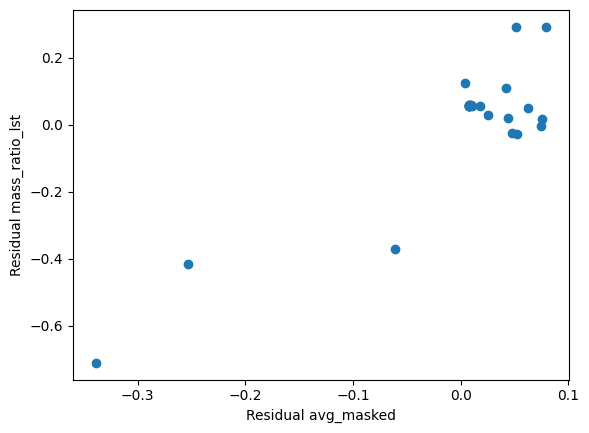

,n,r,CI95%,p-val,BF10,power
pearson,25,0.8793,"[0.74, 0.95]",7.208676e-09,1.671e+06,0.999997


In [413]:
# Regress out kappa_co_lst
from sklearn.linear_model import LinearRegression

X = df[["kappa_co_lst"]]
y_avg = df["avg_masked"].values.reshape(-1, 1)
y_mass = df["mass_ratio_lst"].values.reshape(-1, 1)

res_avg = y_avg - LinearRegression().fit(X, y_avg).predict(X)
res_mass = y_mass - LinearRegression().fit(X, y_mass).predict(X)


plt.scatter(res_avg, res_mass)
plt.xlabel("Residual avg_masked")
plt.ylabel("Residual mass_ratio_lst")
plt.show()

# Correlation of residuals should match partial correlation
pg.corr(res_avg.flatten(), res_mass.flatten())

In [414]:
def plot_net_path(var, win_lst, it_dict, time_lst, grp="in_situ"):
    net_avg = []
    path_avg = []
    k_avg = []
    t_hld = []

    for win in win_lst:
        idxl = win["idxl"]
        idxu = win["idxu"]

        t_cen = np.average((time_lst[idxl], time_lst[idxu]))

        tmin = time_lst[idxl]

        it_net = []
        it_path = []
        it_k = []

        for it_id in it_dict:
            gc_net = []
            gc_path = []
            gc_k = []
            for gcid in it_dict[it_id]:
                if it_dict[it_id][gcid]["grp_type"] != grp:
                    continue
                if it_dict[it_id][gcid]["tval"] < tmin:
                    d_arr = it_dict[it_id][gcid]["d" + var]
                    gc_path_i = np.nansum(np.abs(d_arr[idxl:idxu]))
                    gc_net_i = np.abs(it_dict[it_id][gcid][var][idxu] - it_dict[it_id][gcid][var][idxl])
                    gc_k.append(gc_net_i / gc_path_i)

                    gc_net.append(gc_net_i)
                    gc_path.append(gc_path_i)

                else:
                    continue

            if len(gc_net) != 0:
                it_net.append(np.nanmean(gc_net))
                it_path.append(np.nanmean(gc_path))
                it_k.append(np.nanmedian(gc_k))

        if len(it_net) != 0:
            net_avg.append(np.nanmean(it_net))
            path_avg.append(np.nanmean(it_path))
            k_avg.append(np.nanmean(it_k))
            t_hld.append(t_cen)

    return net_avg, path_avg, k_avg, t_hld

Text(0.5, 0, 'Time (Gyr)')

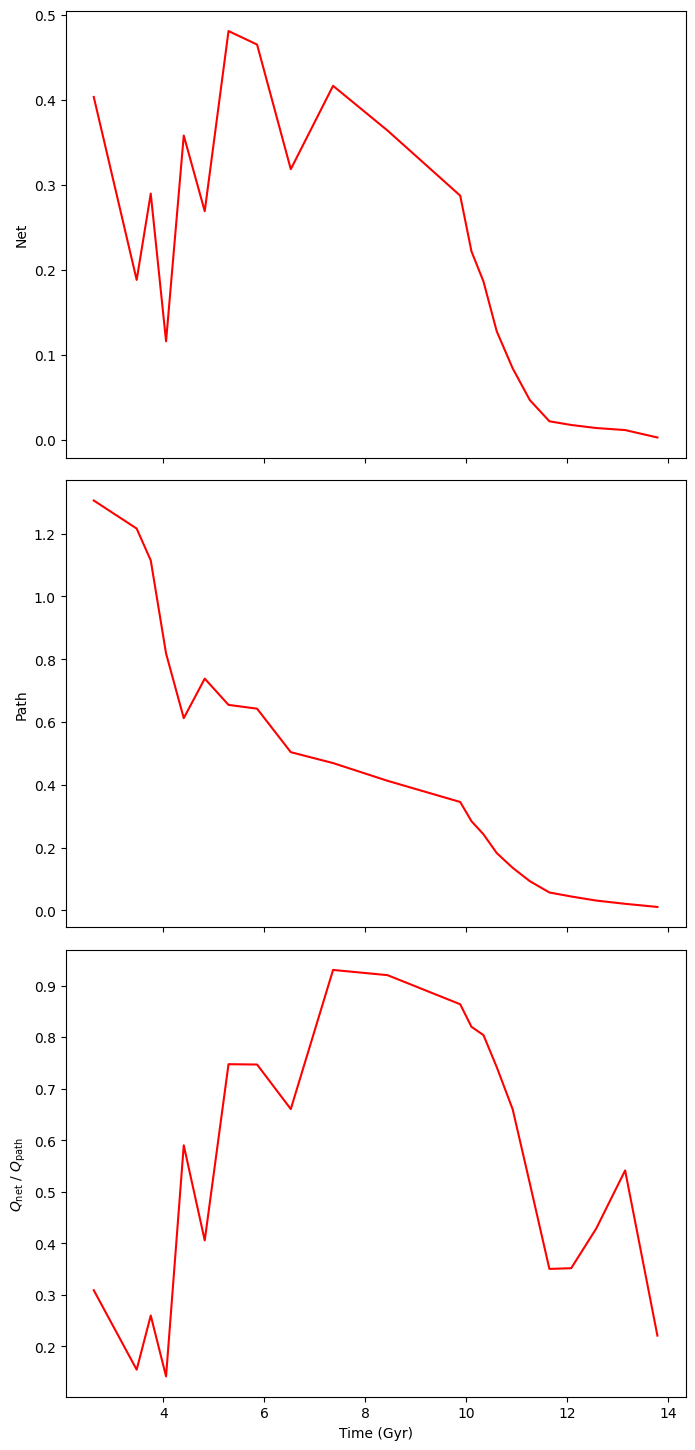

In [602]:
var_lst = ["et_norm", "jr", "jp", "jz"]
plt_lin = ["solid", "dotted", "dashed", "dashdot"]
leg_lst = [r"$\epsilon$", r"$J_{r}$", r"$J_{\phi}$", r"$J_{z}$"]

var_foc = "et_norm"

fig, axs = plt.subplots(3, 1, figsize=(8, 18), sharey=False, sharex=True)
plt.subplots_adjust(hspace=0.05)

for var, lin, leg in zip(var_lst, plt_lin, leg_lst):
    if var != var_foc:
        continue

    net_avg, path_avg, k_avg, t_hld = plot_net_path(var, win_lst, it_dict, time_lst, grp="in_situ")

    axs[0].plot(t_hld, net_avg, c="r", ls=lin, label=leg)
    axs[1].plot(t_hld, path_avg, c="r", ls=lin, label=leg)
    axs[2].plot(t_hld, k_avg, c="r", ls=lin, label=leg)

axs[0].set_ylabel(r"Net")
axs[1].set_ylabel(r"Path")
axs[2].set_ylabel(r"$Q_{\rm net}$ / $Q_{\rm path}$")

axs[2].set_xlabel("Time (Gyr)")

# axs[0].set_yscale("log")
# axs[1].set_yscale("log")

In [600]:
np.max(net_avg[6:]) / net_avg[-1], np.max(path_avg[6:]) / path_avg[-1]

(34.17848069822036, 58.39704225608712)

In [601]:
net_avg[-1] / path_avg[-1]

0.5786365468631771

In [515]:
proc_data["it000"]["snapshots"]["snap600"]["j.cyl"][:, 0]

array([1034.96178398,  850.33134201,  632.11883298,  451.26284426,
         58.90052058,   88.97376279,  629.25527113, 2346.33000195,
        233.43697362,  229.34687244, 3534.22911591,  951.00845103,
        315.34698868, 2201.89249429,  487.30521253, 1119.83112527,
       1905.87163921,  658.15215025,  517.43043173,  369.43860599,
       1521.88724349,  281.47200117, 1228.49443916, 1228.27538007,
        152.04787758, 1285.78196073, 1204.62541458,  772.0873291 ,
       1624.6672651 ,  896.15018797, 1154.58840587,  846.49385058,
       2964.77590321, 1241.52697358, 1115.30062217, 1954.38147932,
        244.81227511, 2473.80653613,  179.71535241, 2029.04851012,
        154.93024699, 1125.8502451 , 1108.77903707,  635.5731213 ,
        589.22536404,  606.98218766,   48.9328391 ,   55.86121875,
        465.59129862,  802.38023901,  490.42001604, 1361.72429528,
        656.89373648,  602.91531569,  539.79377221, 1691.76065813,
        275.65336172,  230.38139937,   48.95914366, 1193.54595

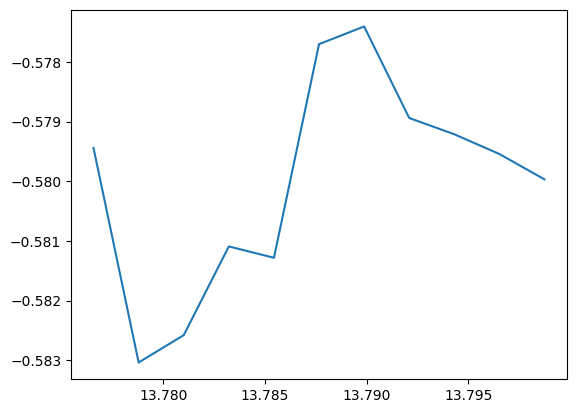

In [580]:
# proc_data["it000"]["snapshots"]["snap600"]["gc_id"][()]
it_id = "it000"
snap_test_lim = 590
# snap_test_lim = 250
gcid = 57057454
gcid = 31606918

# gcid = proc_data["it000"]["snapshots"]["snap600"]["gc_id"][()]

time = pub_snaps[pub_snaps["index"] >= snap_test_lim]["time_Gyr"]
ep = []
ek = []
et = []
jr = []
dep = []
for snap_id in proc_data["it000"]["snapshots"].keys():
    if int(snap_id[4:]) < snap_test_lim:
        continue

    snp_dat = proc_data["it000"]["snapshots"][snap_id]
    gcid_msk = np.isin(snp_dat["gc_id"][()], gcid)

    et_i = snp_dat["et"][gcid_msk]
    et_norm = snp_dat["et_norm"][gcid_msk]
    pot_dep = et_i / et_norm

    ep.append(snp_dat["ep_agama"][gcid_msk] / pot_dep)
    ek.append(snp_dat["ek"][gcid_msk] / pot_dep)
    et.append(et_norm)
    dep.append(pot_dep)
    jr.append(snp_dat["j.cyl"][:, 0][gcid_msk])

# plt.plot(time, ep)
# plt.plot(time, ek)
plt.plot(time, et)
# plt.plot(time, np.median(ek, axis=1))
# plt.plot(time, np.array(jr) / jr[-1], c="r")
# plt.plot(time, np.array(et) / et[-1], c="g")
# plt.plot(time, dep)